In [1]:
!pip install fastapi
!pip install ultralytics
!pip install supervision
!pip install uvicorn
!pip install paddleocr paddlepaddle
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
     -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
     ----- ---------------------------------- 0.5/4.1 MB 1.4 MB/s eta 0:00:03
     ------- -------------------------------- 0.8/4.1 MB 1.0 MB/s eta 0:00:04
     ---------- ----------------------------- 1.0/4.1 MB 1.2 MB/s eta 0:00:03
     ------------ --------------------------- 1.3/4.1 MB 1.1 MB/s eta 0:00:03
     ------------ --------------------------- 1.3/4.1 MB 1.1 MB/s eta 0:00:03
     --------------- ------------------------ 1.6/4.1 MB 953.2 kB/s eta 0:00:03
     --------------- -------------------

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)

True
NVIDIA GeForce RTX 4060 Laptop GPU
12.1


In [2]:
import re
import cv2 as cv
import ultralytics
import numpy as np
from PIL import Image
import supervision as sv
from ultralytics import YOLO
from paddleocr import PaddleOCR
import matplotlib.pyplot as plt

ultralytics.checks()

Ultralytics 8.3.208  Python-3.11.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (32 CPUs, 31.7 GB RAM, 432.8/951.6 GB disk)


In [3]:
model = YOLO("yolo11n.pt")

In [ ]:
model.train(
    data="./Plat Nomor Kendaraan Indonesia.v1i.yolov11/data.yaml",
    epochs=60,
    imgsz=640,
    batch=16,
    project="runs/ptc_train",
    name="yolo11n_ptc",
    pretrained=True
)

In [3]:
class PlatNomor:
    def __init__(self, model_path: str):
        self.model = YOLO(model_path)

    def predict(self, image_path):
        image = Image.open(image_path).convert("RGB")
        image_cv = np.array(image)[..., ::-1]  

        results = self.model(image_cv)
        detections = sv.Detections.from_ultralytics(results[0])

        annotated = sv.BoxAnnotator().annotate(scene=image_cv.copy(), detections=detections)

        license_plates = self.extract_license_plates(image_cv, detections)

        return annotated[..., ::-1], license_plates


    def extract_license_plates(self, image, detections):
        plates = []
        for xyxy in detections.xyxy:
            x1, y1, x2, y2 = map(int, xyxy)
            crop = image[y1:y2, x1:x2]
            plates.append(crop)
        return plates


In [4]:
model_path = "runs/ptc_train/yolo11n_ptc/weights/best.pt"
detector = PlatNomor(model_path)

In [22]:
ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False)

plate_pattern = re.compile(r"[A-Z]{1,2}\s*\d{1,4}\s*[A-Z]{1,3}")

Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Frederick\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Frederick\.paddlex\official_models\PP-OCRv5_server_rec`.


0: 480x640 1 Plat Nomor, 19.4ms
Speed: 56.0ms preprocess, 19.4ms inference, 3.5ms postprocess per image at shape (1, 3, 480, 640)


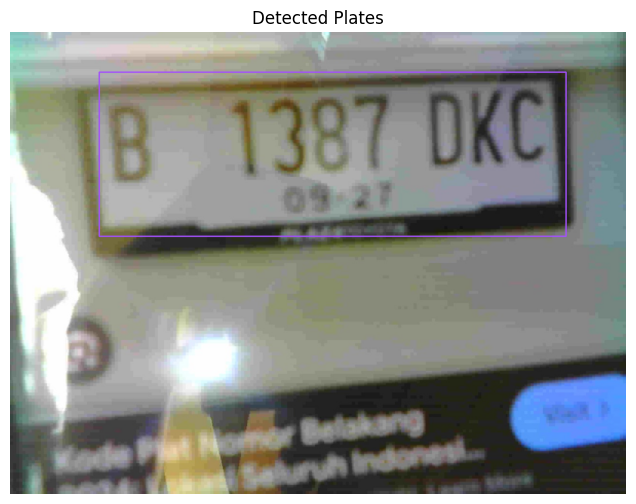

In [23]:
image_path = "image.jpg"
# image_path = "image.png"
annotated_img, plate_crops = detector.predict(image_path)   

plt.figure(figsize=(10, 6))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("Detected Plates")
plt.show()

In [7]:
def auto_rotate_crop(crop):
    gray = cv.cvtColor(crop, cv.COLOR_BGR2GRAY)
    edges = cv.Canny(gray, 50, 150)
    lines = cv.HoughLines(edges, 1, np.pi / 180, 100)
    if lines is None:
        return crop 

    angles = []
    for _, theta in lines[:, 0]:
        angle = (theta * 180 / np.pi) - 90
        if -45 < angle < 45: 
            angles.append(angle)
    if len(angles) == 0:
        return crop

    median_angle = np.median(angles)
    (h, w) = crop.shape[:2]
    M = cv.getRotationMatrix2D((w // 2, h // 2), median_angle, 1.0)
    rotated = cv.warpAffine(crop, M, (w, h), flags=cv.INTER_LINEAR, borderMode=cv.BORDER_REPLICATE)
    return rotated


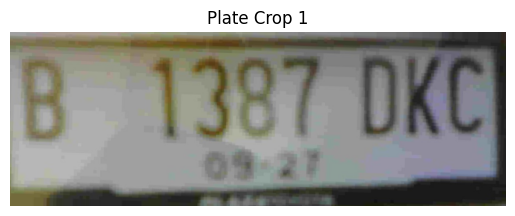

Detected Plate: B1387 DKC


In [24]:
for i, crop in enumerate(plate_crops):
    fixed_crop = auto_rotate_crop(crop)

    fixed_crop_rgb = cv.cvtColor(fixed_crop, cv.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(fixed_crop_rgb)
    plt.axis("off")
    plt.title(f"Plate Crop {i+1}")
    plt.show()

    result = ocr.predict(input=fixed_crop_rgb)

    result_text = ""
    plate_candidates = []

    for res in result:
        result_text += "".join(res["rec_texts"])
        
        for text in res["rec_texts"]:
            cleaned = text.replace(" ", "")
            plate_candidates.append(cleaned)

    matches = plate_pattern.findall(result_text)

    detected_plates = []
    for match in matches:
        detected_plates.append({
            "plate": match
        })

    if not detected_plates:
        print("No valid license plate detected")
    else:
        for p in detected_plates:
            print(f"Detected Plate: {p['plate']}")


In [6]:
import cv2
from ultralytics import YOLO

# Load model YOLO
model = YOLO(model_path)  # ganti dengan model lu

# Buka kamera (0 = default webcam)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Camera not found!")
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Jalankan deteksi
    results = model(frame)

    # Gambar bounding box di frame
    annotated_frame = results[0].plot()

    # Tampilkan hasil di window
    cv2.imshow("YOLO Detection", annotated_frame)

    # Tekan 'q' buat keluar
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



0: 480x640 (no detections), 88.6ms
Speed: 52.6ms preprocess, 88.6ms inference, 32.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 21.5ms
Speed: 5.4ms preprocess, 21.5ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 37.4ms
Speed: 1.8ms preprocess, 37.4ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 42.4ms
Speed: 4.3ms preprocess, 42.4ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 32.9ms
Speed: 2.5ms preprocess, 32.9ms inference, 5.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 41.9ms
Speed: 5.0ms preprocess, 41.9ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 30.7ms
Speed: 3.3ms preprocess, 30.7ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 37.1ms
Speed: 2.6ms preprocess, 37.1ms

: 